# Index Hopping correction

In [2]:
suppressPackageStartupMessages({
    library(dplyr)
    library(ggplot2)
    library(Matrix)
    library(scran)
    library(Rtsne)
    library(BiocParallel)
    require(irlba)
    library(batchelor)
    library(stringr)
    library(gridExtra) ## can be replaced by just cowplot
    library(cowplot)
    library(M3C)
    library(Seurat)
    library(tidyr)
    library(DropletUtils)
    library(ggplot2)
    library(cowplot)
    library(Matrix)
})

In [2]:
##==Read in all molecule_info.h5 files from Mixl1 cellranger files==##

wd <- paste0("/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/raw_data/SIGA",LETTERS[1:6],"5/outs/")

molecule_h5 <- paste0(wd, "molecule_info.h5")

In [4]:
##==Run the 6 samples in one instance of swappedDrops (since they're from the same sequencing batch)==##
unswapped = swappedDrops(molecule_h5, get.swapped = TRUE)

#=Calculate the ratio of swapped UMIs=#
ratios = sapply(1:length(unswapped$cleaned), function(i){
  sum(unswapped$swapped[[i]])/(sum(unswapped$cleaned[[i]]) + sum(unswapped$swapped[[i]]))
})

names(ratios) = 1:length(molecule_h5)

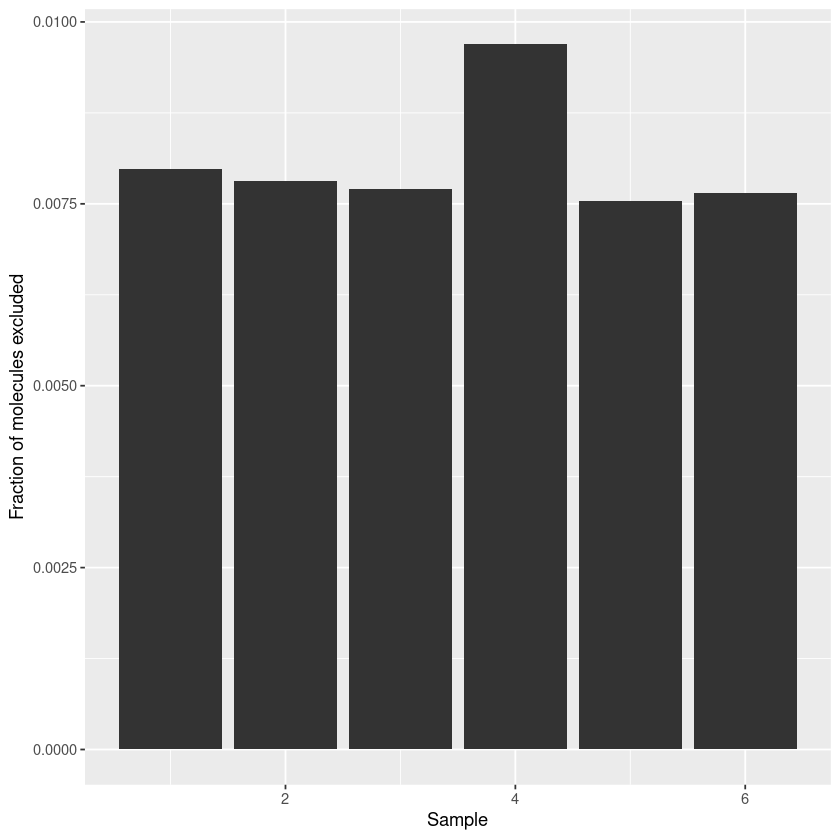

In [5]:
##==Visualize Fraction Swapped per Sample===##

ggplot(data.frame(ratios = ratios, sample = 1:6), aes(x = sample, y = ratios)) + geom_bar(stat = "identity", fill = "grey20") + labs(x = "Sample", y = "Fraction of molecules excluded")

In [6]:
##==Write the Output Directories==##

wd_out <- paste0("/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/raw_data/SIGA",LETTERS[1:6],"5/")

#=Each sample will have 3 files (matrix, barcodes, and gene list)=#

out_loc <- paste0(wd_out, "matrix.mtx")
bc_loc <- paste0(wd_out, "barcodes.tsv")
gene_loc <- paste0(wd_out, "genes.tsv")

In [7]:
#write the output files
for(i in 1:length(molecule_h5)){
  null_holder = writeMM(unswapped$cleaned[[i]], file = out_loc[i])
  write.table(colnames(unswapped$cleaned[[i]]), file = bc_loc[i], col.names = FALSE, row.names = FALSE, quote = FALSE)
  write.table(rownames(unswapped$cleaned[[i]]), file = gene_loc[i], col.names = FALSE, row.names = FALSE, quote = FALSE)
}

# cell calling

In [8]:
library(DropletUtils)
library(ggplot2)
library(Matrix)
library(BiocParallel)
ncores = 3
mcparam = MulticoreParam(workers = ncores)
register(mcparam)

library(knitr)
library(reshape2)


Attaching package: ‘reshape2’


The following object is masked from ‘package:tidyr’:

    smiths




In [9]:
##===Read in files===##
wd <- paste0("/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/raw_data/SIGA",LETTERS[1:6],"5/")

out_loc <- paste0(wd, "matrix.mtx")
bc_loc <- paste0(wd, "barcodes.tsv")
gene_loc <- paste0(wd, "genes.tsv")

In [10]:
# read matrices and tables into a single variable
matrices = bplapply(out_loc, readMM)
bcs = bplapply(bc_loc, function(x) read.table(x, header = FALSE, stringsAsFactors = FALSE)[,1])
               
                    
#correct barcode sample number
for(i in 1:length(bcs)){
  bcs[[i]] = paste0(bcs[[i]], "-", i)
}

In [11]:
##==Create a dataframe with the sample metadata/parameters==##

sample = paste0('mixl_', 1:6)
stage = rep("E8.5", 6)
batch = rep("1", 6)
embryo_pool = 1:6
ID = paste0("SIGA",LETTERS[1:6],"5")

exp_design <- data.frame(sample, stage, batch, embryo_pool, ID)
exp_design

sample,stage,batch,embryo_pool,ID
<chr>,<chr>,<chr>,<int>,<chr>
mixl_1,E8.5,1,1,SIGAA5
mixl_2,E8.5,1,2,SIGAB5
mixl_3,E8.5,1,3,SIGAC5
mixl_4,E8.5,1,4,SIGAD5
mixl_5,E8.5,1,5,SIGAE5
mixl_6,E8.5,1,6,SIGAF5


In [12]:
##==Do cell calling==##

set.seed(42)
#do call
outs = lapply(matrices, emptyDrops, niters = 20000, ignore = 4999, BPPARAM = mcparam, lower = 100, retain = Inf)


#identify cells
sigs = lapply(outs, function(x) x$FDR <= 0.01 & !is.na(x$FDR))

#subset the cells
cells = lapply(1:length(matrices), function(i) matrices[[i]][, sigs[[i]]])
barcodes = lapply(1:length(bcs), function(i) bcs[[i]][sigs[[i]]])

#append
counts = do.call(cbind, cells)
barcodes = do.call(c, barcodes)

In [13]:
##==save==##
out_dir <- ("/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/raw_data/calledcells/")
 
writeMM(counts, file = paste0(out_dir,"raw_counts.mtx"))
write.table(barcodes, file = paste0(out_dir, "barcodes.tsv"), col.names = FALSE, row.names = FALSE, quote = FALSE)
file.copy(from = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/raw_data/SIGAA5/genes.tsv",
          to = paste0(out_dir, "genes.tsv"), overwrite = TRUE)

NULL

[1] TRUE

In [23]:
saveRDS(as(counts, "dgCMatrix"), file = paste0(out_dir,"raw_counts.rds"))

### checking tomato expression

In [3]:
out_dir <- ("/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/raw_data/calledcells/")
counts =   readRDS(paste0(out_dir,"raw_counts.rds"))

In [5]:
plot_folder = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/plots/"
out_folder = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/data/"

In [6]:
mixl_data_in = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/raw_data/calledcells/raw_counts.rds"
mixl_genes_in = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/raw_data/calledcells/genes.tsv"
mixl_meta_in = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/raw_data/calledcells/barcodes.tsv" 

In [7]:
mixl_counts = readRDS(mixl_data_in)
mixl_genes = read.table(mixl_genes_in, stringsAsFactors = F)
mixl_meta = read.table(mixl_meta_in, header = FALSE, sep = "\t", stringsAsFactors = FALSE, comment.char = "$")
colnames(mixl_meta) = 'barcode_sample'
#mixl_meta$cell <- paste0('chim_', mixl_meta$cell)
# annotate mixl counts
rownames(mixl_counts) = mixl_genes[,1] #ensembl
colnames(mixl_counts) = mixl_meta$barcode_sample


In [8]:
mixl_meta$sample = sapply(strsplit(mixl_meta$barcode_sample,"-"), `[`, 2)
mixl_meta$barcode = sapply(strsplit(mixl_meta$barcode_sample,"-"), `[`, 1)

In [9]:
head(mixl_meta)

,barcode_sample,sample,barcode
,<chr>,<chr>,<chr>
1,ACACCAACACGAGGTA-1,1,ACACCAACACGAGGTA
2,ACACCAAGTGTGCCTG-1,1,ACACCAAGTGTGCCTG
3,ACACTGAGTAGCTGCC-1,1,ACACTGAGTAGCTGCC
4,ACAGCCGAGAGGTTAT-1,1,ACAGCCGAGAGGTTAT
5,ACAGCCGCAATGAAAC-1,1,ACAGCCGCAATGAAAC
6,ACAGCCGTCACTCTTA-1,1,ACAGCCGTCACTCTTA


In [10]:
mixl_meta_in2 = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/mlnt/5_doubletDetection/meta.tab"
correct_meta = read.table(mixl_meta_in2, header = TRUE, sep = "\t", stringsAsFactors = FALSE, comment.char = "$")
correct_meta$cell = paste0('chim_', correct_meta$cell)
head(correct_meta)

,cell,barcode,sample,stage,batch,stripped,doublet
,<chr>,<chr>,<int>,<dbl>,<int>,<lgl>,<lgl>
1,chim_cell_1,AAACCCAAGCATAGGC,1,8.5,1,FALSE,FALSE
2,chim_cell_2,AAACCCAAGGGACTGT,1,8.5,1,FALSE,FALSE
3,chim_cell_3,AAACCCACAAGCAATA,1,8.5,1,FALSE,FALSE
4,chim_cell_4,AAACCCACATCTTCGC,1,8.5,1,FALSE,FALSE
5,chim_cell_5,AAACCCAGTATCTCTT,1,8.5,1,FALSE,FALSE
6,chim_cell_6,AAACCCAGTCCAATCA,1,8.5,1,FALSE,FALSE


In [11]:
merge_meta = merge(mixl_meta, correct_meta, by=c('sample','barcode'), all.x=TRUE)

In [12]:
merge_meta  = merge_meta %>% filter(stripped == FALSE & doublet == FALSE)

In [13]:
nrow(merge_meta)

[1] 586

In [14]:
out_folder = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/data/"
correct_sce = readRDS(paste0(out_folder,"mixl_sce.rds"))

In [15]:
correct_sce_red = correct_sce[,merge_meta$cell]

In [16]:
mixl_counts_red = mixl_counts[,merge_meta$barcode_sample]
colnames(mixl_counts_red) = merge_meta$cell

In [17]:
compare = data.frame('new' = colSums(mixl_counts_red), 'original' = colSums(correct_sce_red@assays@data$counts))

In [18]:
head(compare)

,new,original
,<dbl>,<dbl>
chim_cell_449,20082,20203
chim_cell_463,17592,17766
chim_cell_471,11086,11184
chim_cell_472,20604,20728
chim_cell_476,19400,19541
chim_cell_629,9679,9748


png 
  2

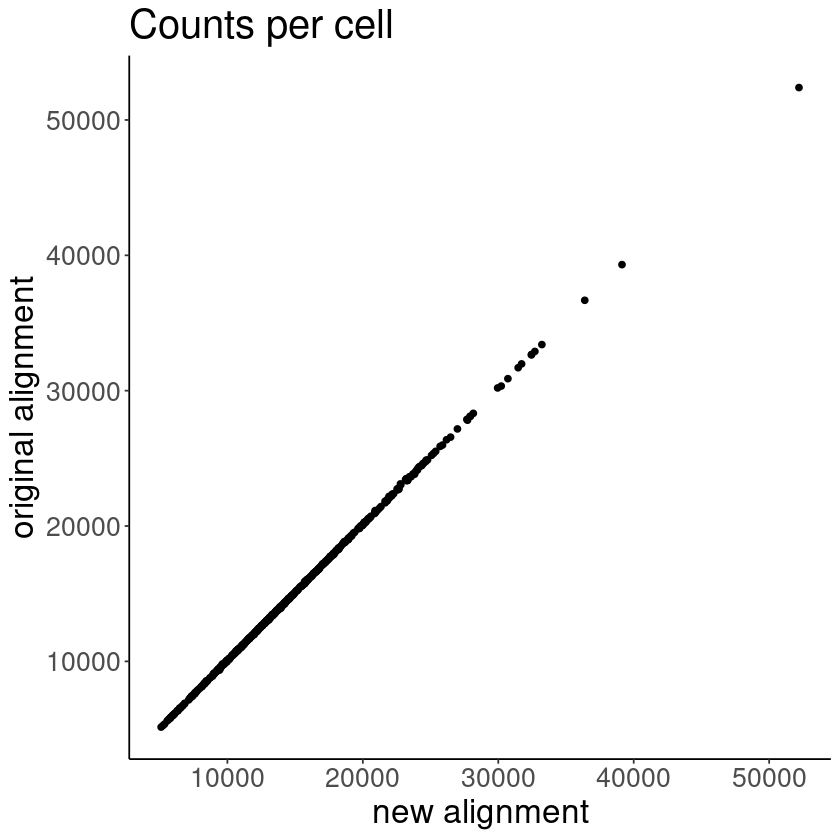

In [19]:
plot_comparison = ggplot(compare, aes(new, original)) + 
        geom_point() + 
        labs(x = "new alignment", y = "original alignment") +
        ggtitle('Counts per cell') +
        theme_classic() +
        theme(text = element_text(size = 20))  
plot_comparison

pdf(paste0(plot_folder, "expression_comparison.pdf"), height=10, width=10)
    plot_comparison
dev.off()

In [20]:
collection <- read.csv("/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/data/chim_collection_meta.csv")
# collection$sample <- paste0('mixl_',collection$sample)
# collection$stage <- paste0('E',collection$stage)
collection$tdTom <- sapply(strsplit(collection$Sample.Name,"_"), `[`, 3)
collection$tdTom <- str_replace(collection$tdTom, c("tdTomPOS","tdTomNEG"), c('pos', 'neg'))
collection <- collection %>% select(stage, ID, tdTom) %>% arrange(ID)
collection$sample = 1:6

In [21]:
merge_meta = merge(merge_meta, collection, by='sample')

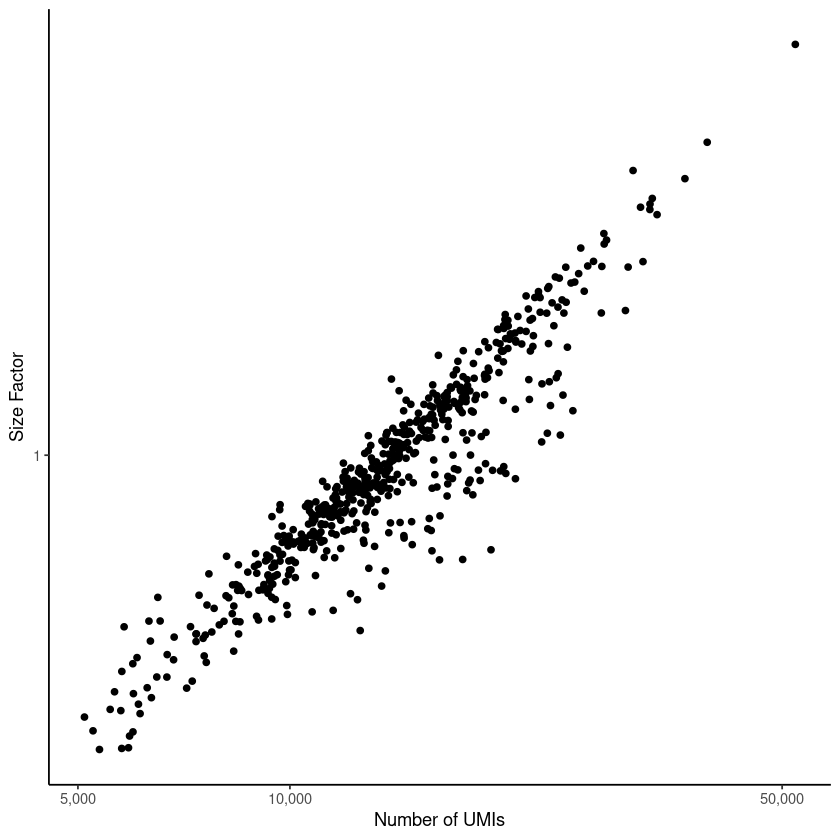

In [22]:
big_sce <- SingleCellExperiment(assays = list("counts" = mixl_counts_red))

# calculate sizefactors
clusts = as.numeric(quickCluster(big_sce, method = "igraph", min.size = 100, BPPARAM = mcparam))
min.clust = min(table(clusts))/2
new_sizes = c(floor(min.clust/3), floor(min.clust/2), floor(min.clust))
big_sce = computeSumFactors(big_sce, clusters = clusts, sizes = new_sizes, max.cluster.size = 3000)
write.table(sizeFactors(big_sce), quote = F, col.names = F, row.names = F, file = paste0(out_folder,"sizefactors_new_alignment.tab"))

# plot
lib.sizes = Matrix::colSums(counts(big_sce))
ggplot(data = data.frame(X = lib.sizes, Y = sizeFactors(big_sce)),
              mapping = aes(x = X, y = Y)) +
  geom_point() +
  scale_x_log10(breaks = c(5000, 10000, 50000, 100000), labels = c("5,000", "10,000", "50,000", "100,000") ) +
  scale_y_log10(breaks = c(0.2, 1, 5)) +
  labs(x = "Number of UMIs", y = "Size Factor") + 
    theme_classic()

# Normalize
sfs = read.table(paste0(out_folder,"sizefactors_new_alignment.tab"), stringsAsFactors = F)[,1]
sizeFactors(big_sce) = sfs
big_sce = scater::logNormCounts(big_sce)

In [23]:
merge_meta$tomato = big_sce@assays@data$logcounts['tomato-td',]

In [26]:
merge_meta$sample = paste0('mixl_', merge_meta$sample)

In [24]:
head(merge_meta)

,sample,barcode,barcode_sample,cell,stage.x,batch,stripped,doublet,stage.y,ID,tdTom,tomato
,<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<lgl>,<lgl>,<dbl>,<chr>,<chr>,<dbl>
1,1,ACACCAAGTGTGCCTG,ACACCAAGTGTGCCTG-1,chim_cell_449,8.5,1,FALSE,FALSE,8.5,SIGAA5,neg,0
2,1,ACACTGAGTAGCTGCC,ACACTGAGTAGCTGCC-1,chim_cell_463,8.5,1,FALSE,FALSE,8.5,SIGAA5,neg,0
3,1,ACAGCCGAGAGGTTAT,ACAGCCGAGAGGTTAT-1,chim_cell_471,8.5,1,FALSE,FALSE,8.5,SIGAA5,neg,0
4,1,ACAGCCGCAATGAAAC,ACAGCCGCAATGAAAC-1,chim_cell_472,8.5,1,FALSE,FALSE,8.5,SIGAA5,neg,0
5,1,ACAGCCGTCACTCTTA,ACAGCCGTCACTCTTA-1,chim_cell_476,8.5,1,FALSE,FALSE,8.5,SIGAA5,neg,0
6,1,ACGATGTAGGGCATGT,ACGATGTAGGGCATGT-1,chim_cell_629,8.5,1,FALSE,FALSE,8.5,SIGAA5,neg,0


png 
  2

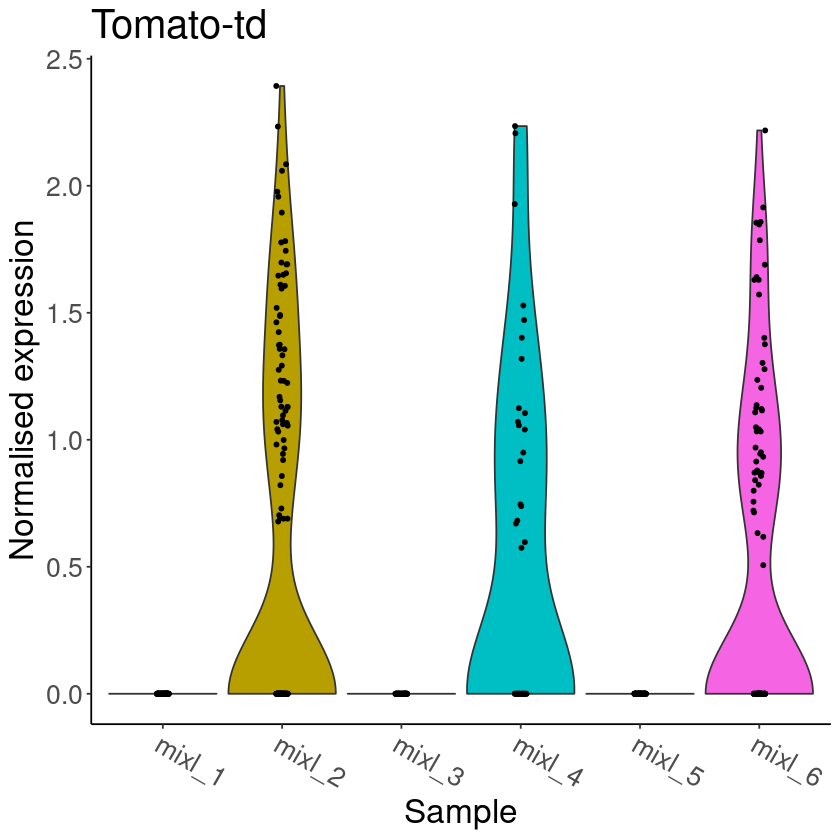

In [33]:
expression_plot = ggplot(merge_meta, aes(sample, tomato, fill=ID)) +
                    geom_violin(scale = 'width') +
                    geom_point(
                       position = position_jitterdodge(jitter.width = 0.1),
                       size =1, alpha = 1) +
                    theme_classic() + 
                    labs(x = "Sample", y = "Normalised expression") +
                    ggtitle('Tomato-td') +
                    theme(text = element_text(size = 20), axis.text.x = element_text(angle = -30, hjust = 0), legend.position = "none") 

expression_plot

pdf(paste0(plot_folder, "tomato_expression.pdf"), height=7, width=7)
    expression_plot
dev.off()

In [ ]:
## similar plot for Mixl & Xist on old data
out_folder = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/data/"
big_sce <- readRDS(paste0(out_folder, "big_sce_norm.rds"))
big_meta = read.table(paste0(out_folder,"big_meta_mapping.tab"), header = TRUE, sep = "\t", stringsAsFactors = FALSE, comment.char = "$")
gene_meta =  read.table("/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/gene_id_name_conversion.csv", header = TRUE, sep = ",")

gene_meta = gene_meta %>% select(gene_id, gene_name)

meta = big_meta %>% filter(tdTom != 'NA') %>% select(cell, sample, tdTom)
chim = big_sce[,meta$cell]

rm(big_sce)

counts = as.data.frame(chim@assays@data$logcounts)
counts$gene_id = rownames(counts)
counts = merge(counts, gene_meta, by='gene_id')

In [ ]:
meta$Xist = counts$Xist
meta$Mixl1 = counts$Mixl1

In [ ]:
head(counts)

# Update TdTom annotation on Metadata!

In [173]:
# Big meta with mapping

big_meta = read.table(paste0(out_folder,"big_meta_mapping.tab"), header = TRUE, sep = "\t", stringsAsFactors = FALSE, comment.char = "$")

big_meta$tdTom = NULL
big_meta$tdTom[big_meta$sample %in% c('mixl_1', 'mixl_3', 'mixl_5')] <- "neg"
big_meta$tdTom[big_meta$sample %in% c('mixl_2', 'mixl_4', 'mixl_6')] <- "pos"

### save big meta with mapping
write.table(big_meta, file = paste0(out_folder,"big_meta_mapping.tab"), row.names = F, col.names = T, quote = F, sep = "\t")

In [180]:
# big meta without mapping
big_meta = read.table(paste0(out_folder,"big_meta.tab"), header = TRUE, sep = "\t", stringsAsFactors = FALSE, comment.char = "$")

big_meta$tdTom = NULL
big_meta$tdTom[big_meta$sample %in% c('mixl_1', 'mixl_3', 'mixl_5')] <- "neg"
big_meta$tdTom[big_meta$sample %in% c('mixl_2', 'mixl_4', 'mixl_6')] <- "pos"

### save big meta with mapping
write.table(big_meta, file = paste0(out_folder,"big_meta.tab"), row.names = F, col.names = T, quote = F, sep = "\t")